In [1]:
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import get_total_norm, clip_grad_norm_

SEED = 42

TRAIN_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv"
TEST_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv"

OUTPUT_DIR = Path("/kaggle/working/fashion_mnist_stability")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 30
TRAIN_SUBSET_SIZE = 2000
VALIDATION_SIZE = 10000
TRAIN_BATCH_SIZE = 64
EVAL_BATCH_SIZE = 512
LEARNING_RATE = 0.01

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [3]:
# Данные грузим один раз и сразу целиком кладём на DEVICE. Набор маленький
# (train 2000 x 784, val 10000, test 10000), поэтому в цикле обучения уже не
# нужно на каждом батче гонять тензоры CPU -> GPU.

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

X_all = torch.tensor(train_df.drop(columns=["label"]).values, dtype=torch.float32) / 255.0
y_all = torch.tensor(train_df["label"].values, dtype=torch.long)

X_test = torch.tensor(test_df.drop(columns=["label"]).values, dtype=torch.float32) / 255.0
y_test = torch.tensor(test_df["label"].values, dtype=torch.long)

# Фиксированное разбиение train / validation: один и тот же seed, поэтому
# каждый эксперимент видит одни и те же объекты.
set_seed(SEED)
indices = torch.randperm(len(X_all))
train_indices = indices[:TRAIN_SUBSET_SIZE]
val_indices = indices[TRAIN_SUBSET_SIZE:TRAIN_SUBSET_SIZE + VALIDATION_SIZE]

X_train = X_all[train_indices].to(DEVICE)
y_train = y_all[train_indices].to(DEVICE)
X_val = X_all[val_indices].to(DEVICE)
y_val = y_all[val_indices].to(DEVICE)
X_test = X_test.to(DEVICE)
y_test = y_test.to(DEVICE)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2000
Validation: 10000
Test: 10000


In [4]:
class MLP(nn.Module):
    """MLP 784 -> 512 -> 512 -> 256 -> 256 -> 128 -> 10.

    Блок скрытого слоя: Linear -> (BatchNorm) -> ReLU -> (Dropout).
    Сеть собирается циклом в nn.Sequential, чтобы не повторять один и тот же
    блок шесть раз во forward.
    """

    def __init__(self, init_method="standard", dropout=0.0, batch_norm=False):
        super().__init__()
        sizes = [784, 512, 512, 256, 256, 128, 10]
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            is_output = i == len(sizes) - 2
            if not is_output:
                if batch_norm:
                    layers.append(nn.BatchNorm1d(sizes[i + 1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)
        self._init_weights(init_method)

    def _init_weights(self, init_method):
        if init_method == "standard":
            return  # оставляем инициализацию nn.Linear по умолчанию
        for layer in self.net:
            if not isinstance(layer, nn.Linear):
                continue
            if init_method == "xavier":
                nn.init.xavier_uniform_(layer.weight, gain=nn.init.calculate_gain("relu"))
            elif init_method == "he":
                nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
            else:
                raise ValueError(f"Unknown initialization: {init_method}")
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

In [5]:
def grad_norm(parameters):
    """L2-норма ГРАДИЕНТОВ (а не весов) переданных параметров.

    get_total_norm считает норму тех тензоров, что ему дали. Поэтому передаём
    именно .grad, иначе получили бы норму самих весов.
    """
    grads = [p.grad for p in parameters if p.grad is not None]
    return get_total_norm(grads, norm_type=2.0)


def mean_item(tensors):
    """Среднее по списку 0-мерных тензоров -> python float (один .item())."""
    return torch.stack(tensors).mean().item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = torch.zeros((), device=DEVICE)
    correct = torch.zeros((), device=DEVICE)
    total = 0
    for X, y in loader:
        logits = model(X)
        total_loss += criterion(logits, y) * X.size(0)
        correct += (logits.argmax(dim=1) == y).sum()
        total += X.size(0)
    return (total_loss / total).item(), (correct / total).item()

In [6]:
def run_experiment(experiment_name, group, init_method="standard", dropout=0.0,
                   batch_norm=False, weight_decay=0.0, early_stopping=False,
                   patience=5, gradient_clipping=False, max_grad_norm=1.0):

    print("\n" + "=" * 70)
    print(experiment_name)
    print("=" * 70)

    # Один и тот же seed перед каждым запуском: одинаковые стартовые веса
    # (при standard-инициализации Linear создаются в том же порядке и из того
    # же потока RNG) и одинаковый порядок перемешивания батчей.
    set_seed(SEED)

    train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)

    model = MLP(init_method=init_method, dropout=dropout, batch_norm=batch_norm).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=weight_decay)

    # Слои, по которым отслеживаем норму градиента: первый, средний, выходной.
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    tracked_layers = {
        "first": linear_layers[0],
        "middle": linear_layers[len(linear_layers) // 2],
        "last": linear_layers[-1],
    }

    history = {k: [] for k in [
        "epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy",
        "generalization_gap", "first_layer_grad_norm", "middle_layer_grad_norm",
        "last_layer_grad_norm", "total_grad_norm_pre_clip", "total_grad_norm_post_clip",
        "learning_rate", "epoch_time_sec",
    ]}

    best_val_accuracy = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0

    total_start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = torch.zeros((), device=DEVICE)
        correct = torch.zeros((), device=DEVICE)
        total = 0

        first_norms, middle_norms, last_norms = [], [], []
        pre_clip_norms, post_clip_norms = [], []

        for X, y in train_loader:
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()

            # Нормы градиента ДО обрезки. Всё остаётся тензорами на DEVICE и
            # складывается в список — .item() ни разу за батч, GPU не ждёт CPU.
            first_norms.append(grad_norm(tracked_layers["first"].parameters()))
            middle_norms.append(grad_norm(tracked_layers["middle"].parameters()))
            last_norms.append(grad_norm(tracked_layers["last"].parameters()))
            pre_clip_norms.append(grad_norm(model.parameters()))

            if gradient_clipping:
                clip_grad_norm_(model.parameters(), max_norm=max_grad_norm, norm_type=2.0)

            post_clip_norms.append(grad_norm(model.parameters()))

            optimizer.step()

            running_loss += loss.detach() * X.size(0)
            correct += (logits.argmax(dim=1) == y).sum()
            total += X.size(0)

        train_loss = (running_loss / total).item()
        train_accuracy = (correct / total).item()
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        current_lr = optimizer.param_groups[0]["lr"]
        generalization_gap = train_accuracy - val_accuracy

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        epoch_time = time.perf_counter() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["generalization_gap"].append(generalization_gap)
        history["first_layer_grad_norm"].append(mean_item(first_norms))
        history["middle_layer_grad_norm"].append(mean_item(middle_norms))
        history["last_layer_grad_norm"].append(mean_item(last_norms))
        history["total_grad_norm_pre_clip"].append(mean_item(pre_clip_norms))
        history["total_grad_norm_post_clip"].append(mean_item(post_clip_norms))
        history["learning_rate"].append(current_lr)
        history["epoch_time_sec"].append(epoch_time)

        improved = (val_accuracy > best_val_accuracy or
                    (val_accuracy == best_val_accuracy and val_loss < best_val_loss))
        if improved:
            best_val_accuracy = val_accuracy
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch:02d}/{EPOCHS} | train loss={train_loss:.4f} | "
              f"train acc={train_accuracy:.4f} | val loss={val_loss:.4f} | "
              f"val acc={val_accuracy:.4f} | gap={generalization_gap:.4f} | "
              f"grad={history['total_grad_norm_pre_clip'][-1]:.4f}")

        if early_stopping and epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    total_time = time.perf_counter() - total_start

    pd.DataFrame(history).to_csv(OUTPUT_DIR / f"{experiment_name}_history.csv", index=False)

    checkpoint = {
        "model_state_dict": best_state,
        "experiment_name": experiment_name,
        "seed": SEED,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "init_method": init_method,
        "dropout": dropout,
        "batch_norm": batch_norm,
        "weight_decay": weight_decay,
        "early_stopping": early_stopping,
        "gradient_clipping": gradient_clipping,
        "max_grad_norm": max_grad_norm,
    }
    checkpoint_path = OUTPUT_DIR / f"{experiment_name}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    best_i = best_epoch - 1
    result = {
        "experiment": experiment_name,
        "group": group,
        "init_method": init_method,
        "dropout": dropout,
        "batch_norm": batch_norm,
        "weight_decay": weight_decay,
        "early_stopping": early_stopping,
        "gradient_clipping": gradient_clipping,
        "max_grad_norm": max_grad_norm if gradient_clipping else np.nan,
        "best_epoch": best_epoch,
        "train_accuracy_at_best": history["train_accuracy"][best_i],
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "generalization_gap": history["generalization_gap"][best_i],
        "maximum_gradient_norm": np.max(history["total_grad_norm_pre_clip"]),
        "total_time_sec": total_time,
        "checkpoint": str(checkpoint_path),
    }
    return result, history

In [7]:
experiments = [
    {"name": "baseline", "group": "baseline"},

    # Инициализация
    {"name": "xavier", "group": "initialization", "init_method": "xavier"},
    {"name": "he", "group": "initialization", "init_method": "he"},

    # Dropout
    {"name": "dropout", "group": "dropout", "dropout": 0.5},

    # Batch normalization
    {"name": "batch_norm", "group": "batch_normalization", "batch_norm": True},

    # Weight decay
    {"name": "weight_decay_1e-4", "group": "weight_decay", "weight_decay": 1e-4},
    {"name": "weight_decay_1e-3", "group": "weight_decay", "weight_decay": 1e-3},
    {"name": "weight_decay_1e-2", "group": "weight_decay", "weight_decay": 1e-2},

    # Early stopping
    {"name": "early_stopping", "group": "early_stopping", "early_stopping": True, "patience": 5},

    # Gradient clipping
    {"name": "gradient_clipping", "group": "gradient_clipping",
     "gradient_clipping": True, "max_grad_norm": 1.0},
]

In [8]:
results = {}
histories = {}
rows = []

for exp in experiments:
    result, history = run_experiment(
        experiment_name=exp["name"],
        group=exp["group"],
        init_method=exp.get("init_method", "standard"),
        dropout=exp.get("dropout", 0.0),
        batch_norm=exp.get("batch_norm", False),
        weight_decay=exp.get("weight_decay", 0.0),
        early_stopping=exp.get("early_stopping", False),
        patience=exp.get("patience", 5),
        gradient_clipping=exp.get("gradient_clipping", False),
        max_grad_norm=exp.get("max_grad_norm", 1.0),
    )
    rows.append(result)
    results[exp["name"]] = result
    histories[exp["name"]] = history


baseline
Epoch 01/30 | train loss=2.3021 | train acc=0.1070 | val loss=2.3034 | val acc=0.1005 | gap=0.0065 | grad=0.1380
Epoch 02/30 | train loss=2.3017 | train acc=0.1065 | val loss=2.3031 | val acc=0.0999 | gap=0.0066 | grad=0.1411
Epoch 03/30 | train loss=2.3013 | train acc=0.0845 | val loss=2.3029 | val acc=0.0564 | gap=0.0281 | grad=0.1496
Epoch 04/30 | train loss=2.3009 | train acc=0.0970 | val loss=2.3027 | val acc=0.0881 | gap=0.0089 | grad=0.1420
Epoch 05/30 | train loss=2.3006 | train acc=0.1010 | val loss=2.3025 | val acc=0.0984 | gap=0.0026 | grad=0.1405
Epoch 06/30 | train loss=2.3002 | train acc=0.1165 | val loss=2.3022 | val acc=0.0987 | gap=0.0178 | grad=0.1557
Epoch 07/30 | train loss=2.2999 | train acc=0.1150 | val loss=2.3020 | val acc=0.0987 | gap=0.0163 | grad=0.1431
Epoch 08/30 | train loss=2.2995 | train acc=0.1150 | val loss=2.3018 | val acc=0.0987 | gap=0.0163 | grad=0.1486
Epoch 09/30 | train loss=2.2992 | train acc=0.1150 | val loss=2.3015 | val acc=0.0987 

In [9]:
results_df = pd.DataFrame(rows).sort_values("best_val_accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)

display(results_df[[
    "experiment", "group", "init_method", "dropout", "batch_norm", "weight_decay",
    "early_stopping", "gradient_clipping", "best_epoch", "train_accuracy_at_best",
    "best_val_accuracy", "best_val_loss", "generalization_gap",
    "maximum_gradient_norm", "total_time_sec",
]])

,experiment,group,init_method,dropout,batch_norm,weight_decay,early_stopping,gradient_clipping,best_epoch,train_accuracy_at_best,best_val_accuracy,best_val_loss,generalization_gap,maximum_gradient_norm,total_time_sec
0,batch_norm,batch_normalization,standard,0.0,True,0.0000,False,False,18,0.9980,0.8336,0.518770,0.1644,6.044503,6.496429
1,xavier,initialization,xavier,0.0,False,0.0000,False,False,23,0.8885,0.8117,0.538281,0.0768,5.302068,5.257506
2,he,initialization,he,0.0,False,0.0000,False,False,23,0.8580,0.8066,0.547084,0.0514,5.158026,5.345025
3,baseline,baseline,standard,0.0,False,0.0000,False,False,1,0.1070,0.1005,2.303397,0.0065,0.163093,5.868319
4,dropout,dropout,standard,0.5,False,0.0000,False,False,1,0.1045,0.1005,2.303553,0.0040,0.251572,5.551392
5,weight_decay_1e-4,weight_decay,standard,0.0,False,0.0001,False,False,1,0.1070,0.1005,2.303397,0.0065,0.162791,5.350021
6,weight_decay_1e-3,weight_decay,standard,0.0,False,0.0010,False,False,1,0.1070,0.1005,2.303398,0.0065,0.159974,5.352995
7,weight_decay_1e-2,weight_decay,standard,0.0,False,0.0100,False,False,1,0.1070,0.1005,2.303400,0.0065,0.154165,5.360270
8,early_stopping,early_stopping,standard,0.0,False,0.0000,True,False,1,0.1070,0.1005,2.303397,0.0065,0.155745,1.025345
9,gradient_clipping,gradient_clipping,standard,0.0,False,0.0000,False,True,1,0.1070,0.1005,2.303397,0.0065,0.163093,5.481854


In [10]:
best_row = results_df.iloc[0]

print("\nBEST CONFIGURATION")
print(best_row[["experiment", "best_epoch", "best_val_accuracy", "best_val_loss",
                "generalization_gap", "total_time_sec"]])


BEST CONFIGURATION
experiment            batch_norm
best_epoch                    18
best_val_accuracy         0.8336
best_val_loss            0.51877
generalization_gap        0.1644
total_time_sec          6.496429
Name: 0, dtype: object


In [11]:
# Для графиков берём baseline и лучший запуск каждой группы.
plot_names = ["baseline"]
for group in ["initialization", "dropout", "batch_normalization",
              "weight_decay", "early_stopping", "gradient_clipping"]:
    group_df = results_df[results_df["group"] == group]
    if len(group_df) > 0:
        best_group_run = group_df.iloc[0]["experiment"]
        if best_group_run not in plot_names:
            plot_names.append(best_group_run)

plot_names

['baseline',
 'xavier',
 'dropout',
 'batch_norm',
 'weight_decay_1e-4',
 'early_stopping',
 'gradient_clipping']

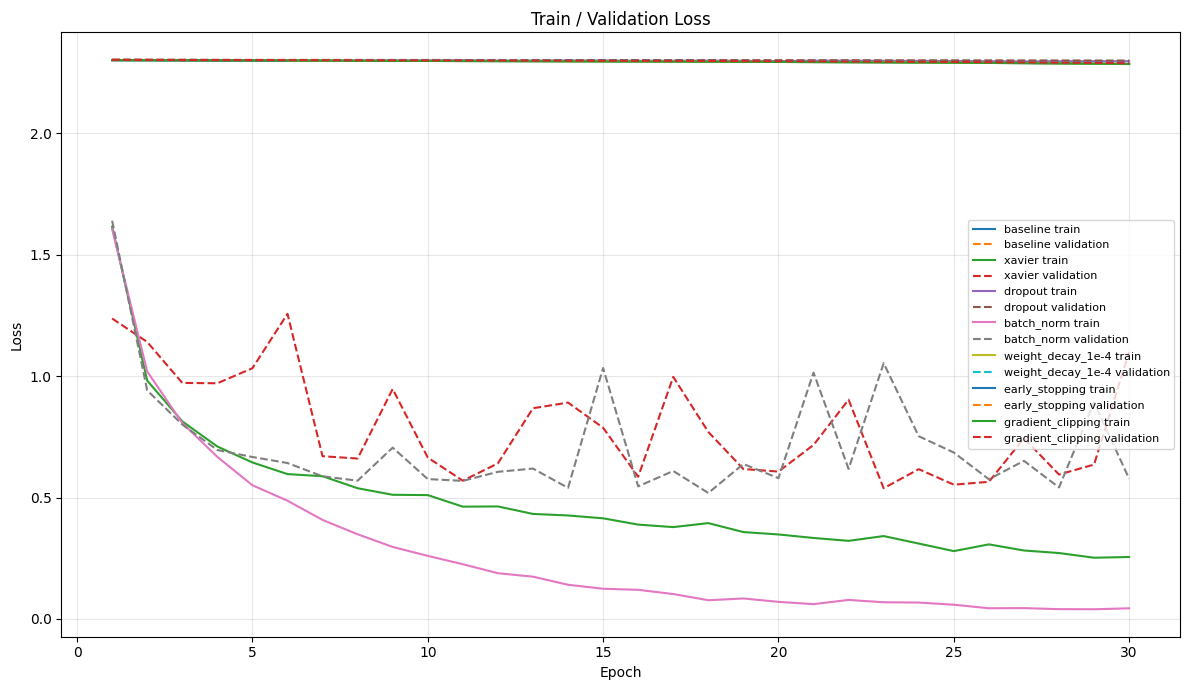

In [12]:
plt.figure(figsize=(12, 7))
for name in plot_names:
    h = histories[name]
    plt.plot(h["epoch"], h["train_loss"], label=f"{name} train")
    plt.plot(h["epoch"], h["val_loss"], linestyle="--", label=f"{name} validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=150)
plt.show()

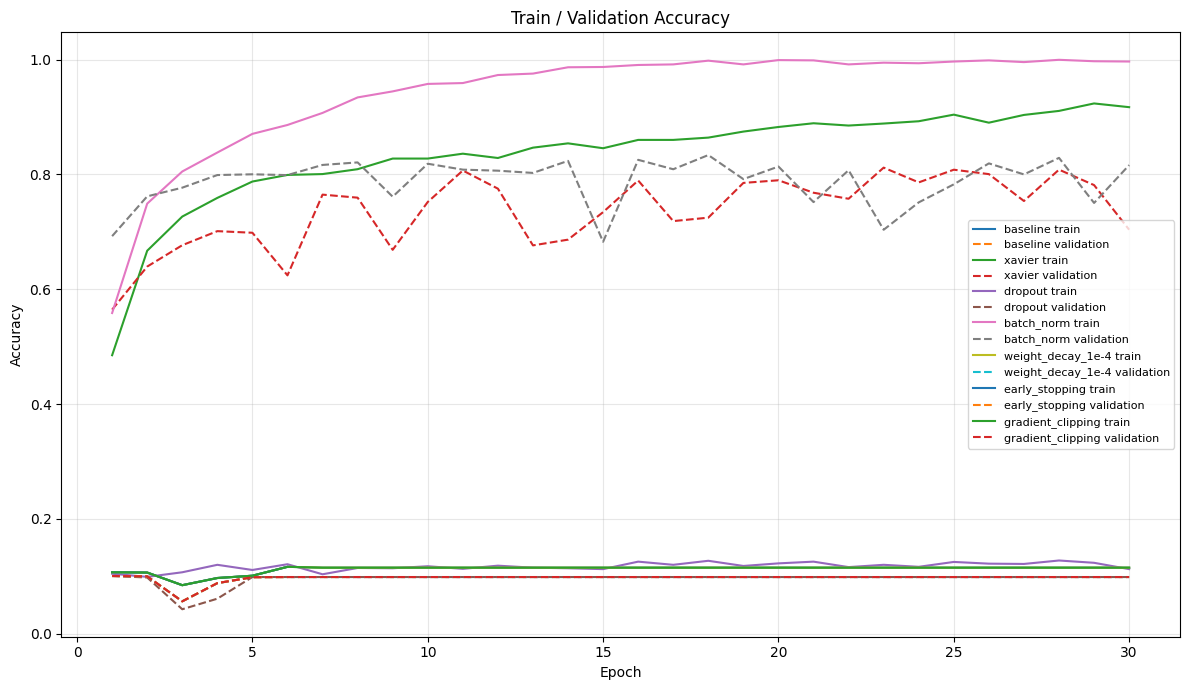

In [13]:
plt.figure(figsize=(12, 7))
for name in plot_names:
    h = histories[name]
    plt.plot(h["epoch"], h["train_accuracy"], label=f"{name} train")
    plt.plot(h["epoch"], h["val_accuracy"], linestyle="--", label=f"{name} validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_curves.png", dpi=150)
plt.show()

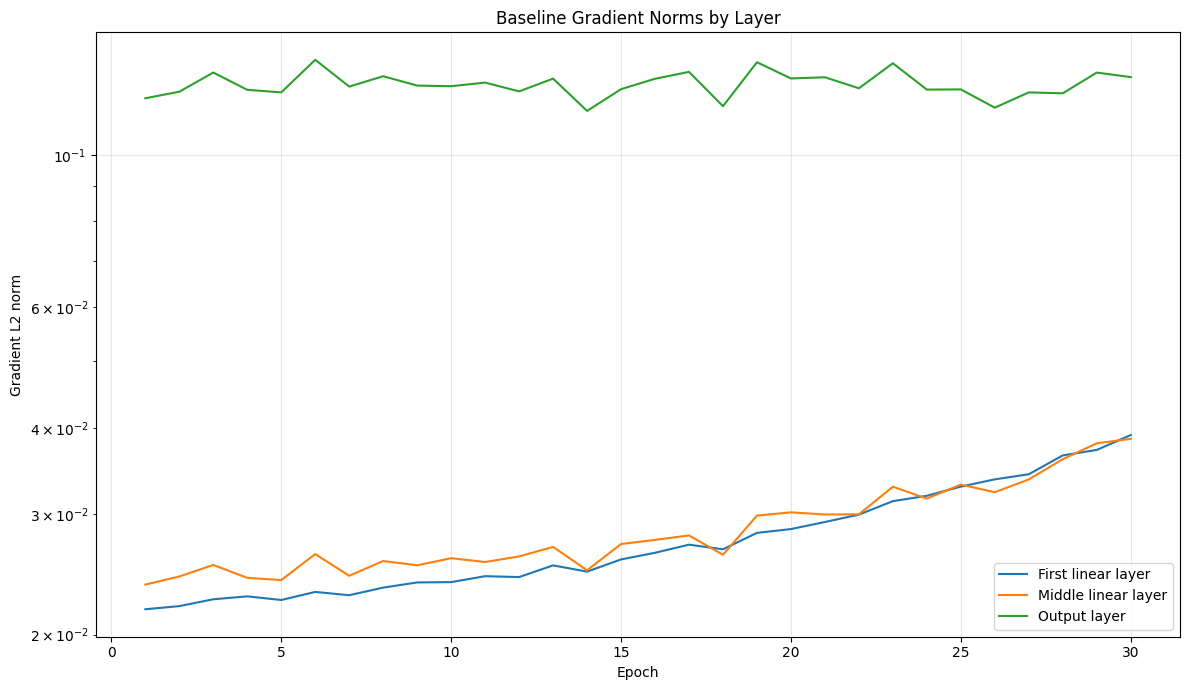

In [14]:
# Нормы градиента по слоям для baseline.
h = histories["baseline"]

plt.figure(figsize=(12, 7))
plt.plot(h["epoch"], h["first_layer_grad_norm"], label="First linear layer")
plt.plot(h["epoch"], h["middle_layer_grad_norm"], label="Middle linear layer")
plt.plot(h["epoch"], h["last_layer_grad_norm"], label="Output layer")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient L2 norm")
plt.title("Baseline Gradient Norms by Layer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_layer_gradient_norms.png", dpi=150)
plt.show()

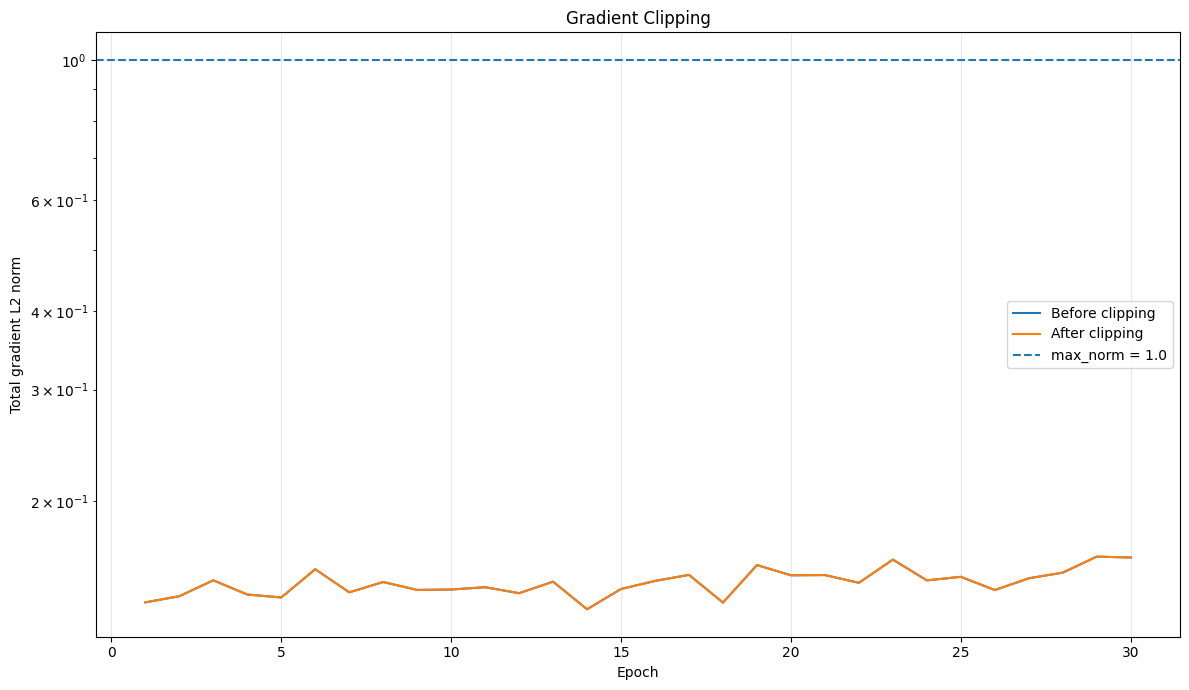

In [15]:
# Норма градиента до и после обрезки (gradient clipping).
h = histories["gradient_clipping"]

plt.figure(figsize=(12, 7))
plt.plot(h["epoch"], h["total_grad_norm_pre_clip"], label="Before clipping")
plt.plot(h["epoch"], h["total_grad_norm_post_clip"], label="After clipping")
plt.axhline(1.0, linestyle="--", label="max_norm = 1.0")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total gradient L2 norm")
plt.title("Gradient Clipping")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradient_clipping.png", dpi=150)
plt.show()

In [16]:
# Финальная проверка лучшего чекпойнта на тесте.
best_checkpoint = torch.load(best_row["checkpoint"], map_location=DEVICE)

best_model = MLP(
    init_method=best_row["init_method"],
    dropout=float(best_row["dropout"]),
    batch_norm=bool(best_row["batch_norm"]),
).to(DEVICE)
best_model.load_state_dict(best_checkpoint["model_state_dict"])

test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = evaluate(best_model, test_loader, criterion)

print("\nFINAL TEST")
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

torch.save(best_checkpoint, OUTPUT_DIR / "best_model.pt")

with open(OUTPUT_DIR / "final_test_metrics.txt", "w") as f:
    f.write(f"Best experiment: {best_row['experiment']}\n")
    f.write(f"Test loss: {test_loss:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")


FINAL TEST
Test loss: 0.5271850228309631
Test accuracy: 0.8341000080108643
